In [53]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)



In [54]:
crop_df = pd.read_csv('../data/raw/crop_recommendation.csv')

crop_df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [55]:
crop_df.shape

(2200, 8)

In [56]:
crop_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 153.0 KB


In [57]:
crop_df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [58]:
crop_df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [59]:
rainfall_df = pd.read_csv('../data/raw/rainfall_india.csv')

In [60]:
rainfall_df.head()

,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JF,MAM,JJAS,OND
0,Andaman & Nicobar Islands,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,332.6,388.5,558.2,33.6,3373.2,136.3,560.3,1696.3,980.3
1,Andaman & Nicobar Islands,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,666.2,197.2,359.0,160.5,3520.7,159.8,458.3,2185.9,716.7
2,Andaman & Nicobar Islands,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,339.0,181.2,284.4,225.0,2957.4,156.7,236.1,1874.0,690.6
3,Andaman & Nicobar Islands,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,820.4,222.2,308.7,40.1,3079.6,24.1,506.9,1977.6,571.0
4,Andaman & Nicobar Islands,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,297.0,260.7,25.4,344.7,2566.7,1.3,309.7,1624.9,630.8


In [61]:
rainfall_df.shape

(4188, 19)

In [62]:
rainfall_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4188 entries, 0 to 4187
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SUBDIVISION  4188 non-null   str    
 1   YEAR         4188 non-null   int64  
 2   JAN          4184 non-null   float64
 3   FEB          4185 non-null   float64
 4   MAR          4182 non-null   float64
 5   APR          4184 non-null   float64
 6   MAY          4185 non-null   float64
 7   JUN          4183 non-null   float64
 8   JUL          4181 non-null   float64
 9   AUG          4184 non-null   float64
 10  SEP          4182 non-null   float64
 11  OCT          4181 non-null   float64
 12  NOV          4177 non-null   float64
 13  DEC          4178 non-null   float64
 14  ANNUAL       4162 non-null   float64
 15  JF           4182 non-null   float64
 16  MAM          4179 non-null   float64
 17  JJAS         4178 non-null   float64
 18  OND          4175 non-null   float64
dtypes: float64(17), i

# Exploratory Data Analysis (EDA)

In [63]:
# Unique Crops
crop_df['label'].nunique()

22

In [64]:
crop_df['label'].unique()

<ArrowStringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str

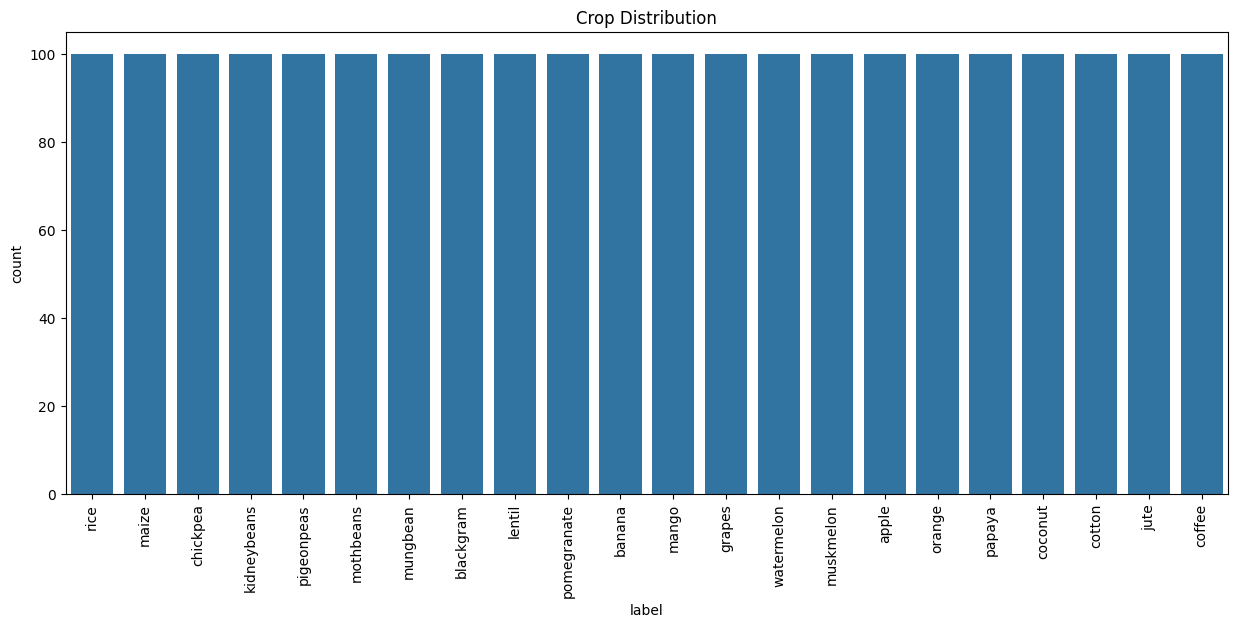

In [65]:
# Crop Distribution

plt.figure(figsize=(15,6))

sns.countplot(
    x='label',
    data=crop_df
)

plt.xticks(rotation=90)

plt.title("Crop Distribution")

plt.show()

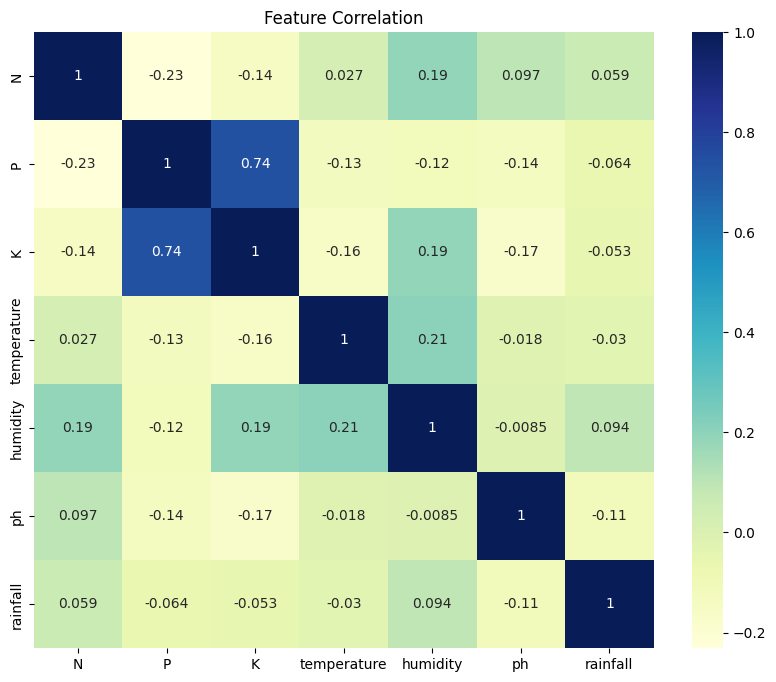

In [66]:
# Correlation Heatmap

plt.figure(figsize=(10,8))

sns.heatmap(
    crop_df.drop('label', axis=1).corr(),
    annot=True,
    cmap='YlGnBu'
)

plt.title("Feature Correlation")

plt.show()

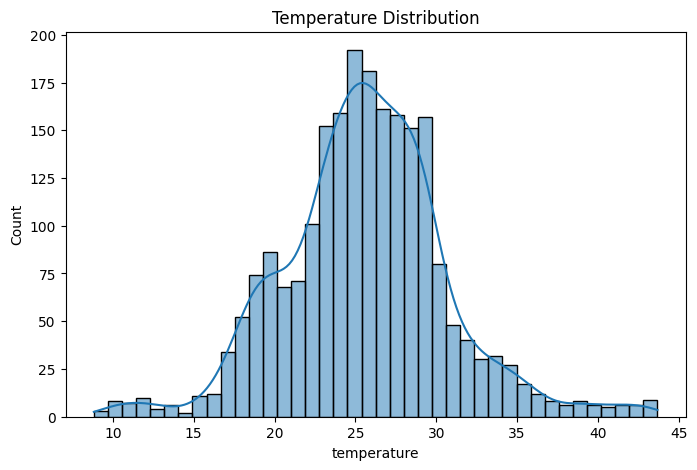

In [67]:
# Temperature Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    crop_df['temperature'],
    kde=True
)

plt.title("Temperature Distribution")

plt.show()

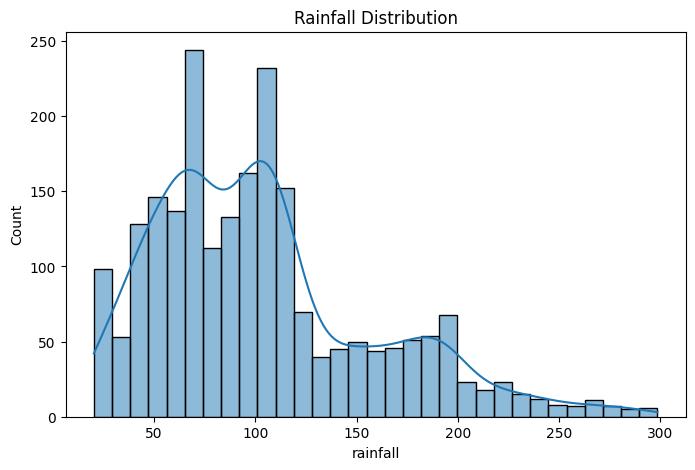

In [68]:
# Rainfall Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    crop_df['rainfall'],
    kde=True
)

plt.title("Rainfall Distribution")

plt.show()

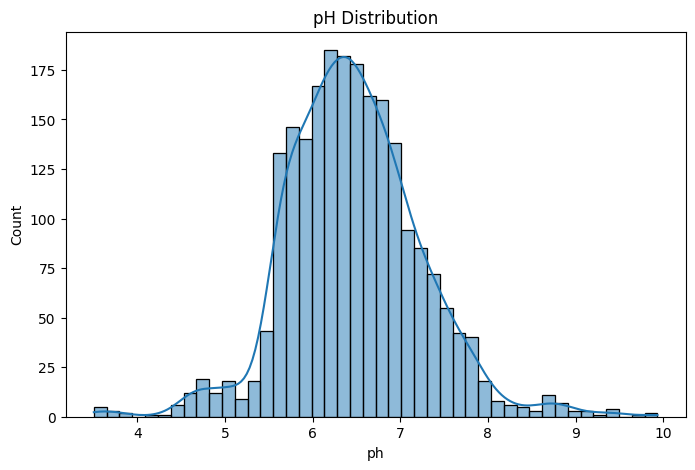

In [69]:
# pH Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    crop_df['ph'],
    kde=True
)

plt.title("pH Distribution")

plt.show()

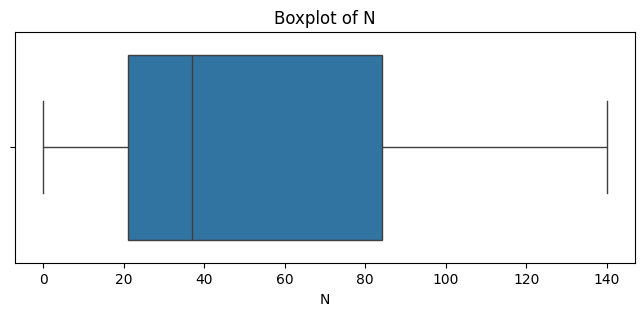

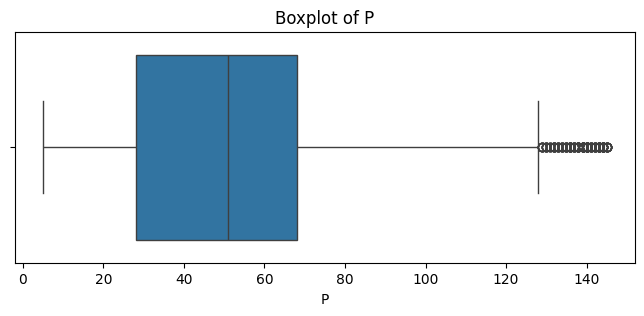

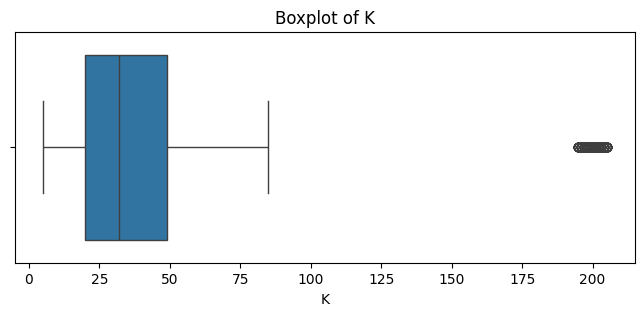

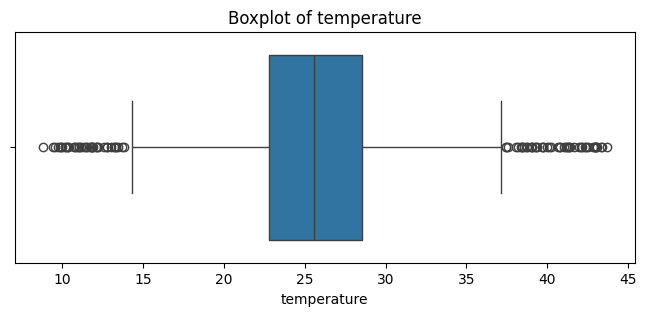

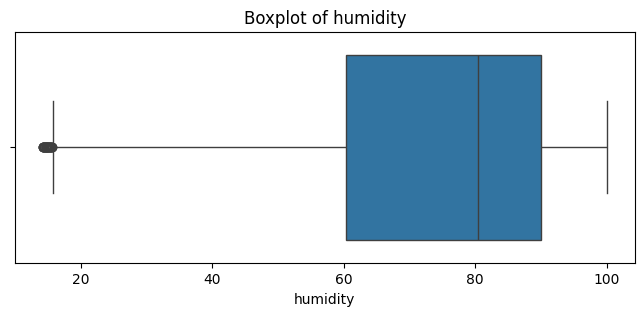

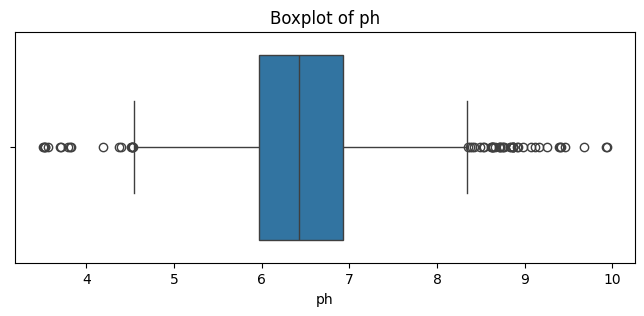

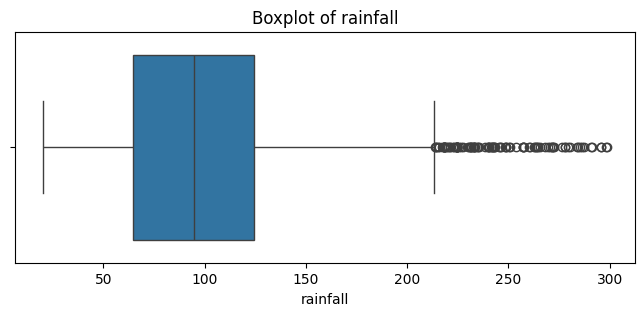

In [70]:
# Boxplots (Outlier Detection)

numeric_cols = crop_df.columns[:-1]

for col in numeric_cols:
    
    plt.figure(figsize=(8,3))
    
    sns.boxplot(
        x=crop_df[col]
    )
    
    plt.title(f'Boxplot of {col}')
    
    plt.show()

# Data Preparation

In [71]:
# Separate Features and Target

X = crop_df.drop('label', axis=1)

y = crop_df['label']

print(X.shape)
print(y.shape)

(2200, 7)
(2200,)


In [72]:
# Check target classes

y.value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [73]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1760, 7)
(440, 7)


# Model Training

In [74]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [75]:
# Accuracy

from sklearn.metrics import accuracy_score

print(
    "Logistic Regression Accuracy:",
    accuracy_score(y_test, lr_pred)
)

Logistic Regression Accuracy: 0.9818181818181818


In [76]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print(
    "Decision Tree Accuracy:",
    accuracy_score(y_test, dt_pred)
)

Decision Tree Accuracy: 0.9795454545454545


In [77]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, rf_pred)
)

Random Forest Accuracy: 0.9954545454545455


In [78]:
# SVM

from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print(
    "SVM Accuracy:",
    accuracy_score(y_test, svm_pred)
)

SVM Accuracy: 0.9840909090909091


In [79]:
# Compare All Models

comparison = {
    "Logistic Regression":
        accuracy_score(y_test, lr_pred),

    "Decision Tree":
        accuracy_score(y_test, dt_pred),

    "Random Forest":
        accuracy_score(y_test, rf_pred),

    "SVM":
        accuracy_score(y_test, svm_pred)
}

comparison

{'Logistic Regression': 0.9818181818181818,
 'Decision Tree': 0.9795454545454545,
 'Random Forest': 0.9954545454545455,
 'SVM': 0.9840909090909091}

# Random Forest Evaluation

In [80]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

<!-- Feature Importance -->

In [81]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
6,rainfall,0.230184
4,humidity,0.224227
2,K,0.175393
1,P,0.150850
0,N,0.096363
3,temperature,0.072375
5,ph,0.050608


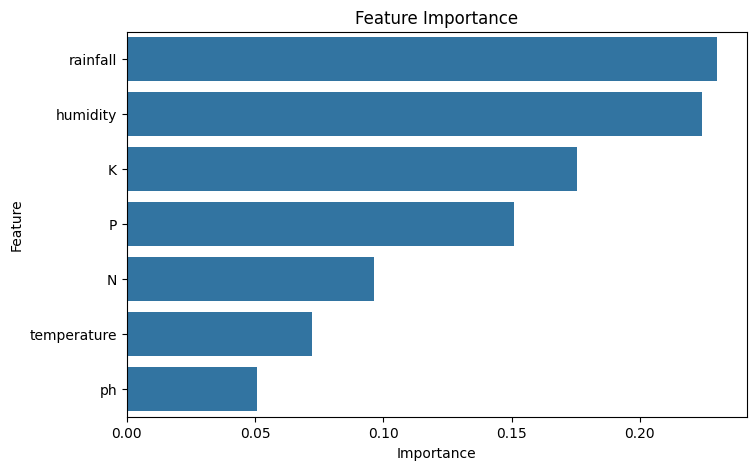

In [82]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance')

plt.show()

<!-- Save Model -->

In [92]:
import pickle

In [84]:
with open(
    '../models/crop_model.pkl',
    'wb'
) as file:

    pickle.dump(
        rf,
        file
    )

In [93]:
import os

print(os.path.exists('../models/crop_model.pkl'))
print(os.path.getsize('../models/crop_model.pkl'))

True
3568330


<!-- Test Model Prediction -->

In [88]:
sample = pd.DataFrame(
    [[90,42,43,20.8,82,6.5,202]],
    columns=[
        'N',
        'P',
        'K',
        'temperature',
        'humidity',
        'ph',
        'rainfall'
    ]
)

rf.predict(sample)

array(['rice'], dtype=object)

# Top-3 Crop Recommendations

In [87]:
# Top-3 Crop Recommendations

probabilities = rf.predict_proba(sample)[0]

classes = rf.classes_

top_3 = sorted(
    zip(classes, probabilities),
    key=lambda x: x[1],
    reverse=True
)[:3]

top_3

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


[('rice', np.float64(0.9)),
 ('jute', np.float64(0.1)),
 ('apple', np.float64(0.0))]

# Confusion Matrix

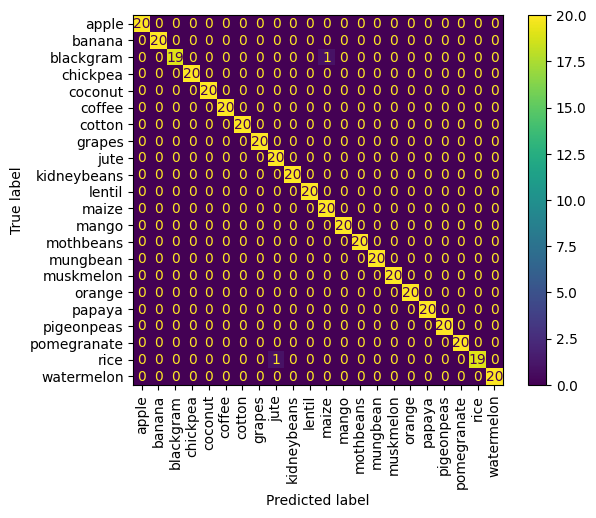

In [89]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    xticks_rotation=90
)

plt.show()

# Classification Report

In [90]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

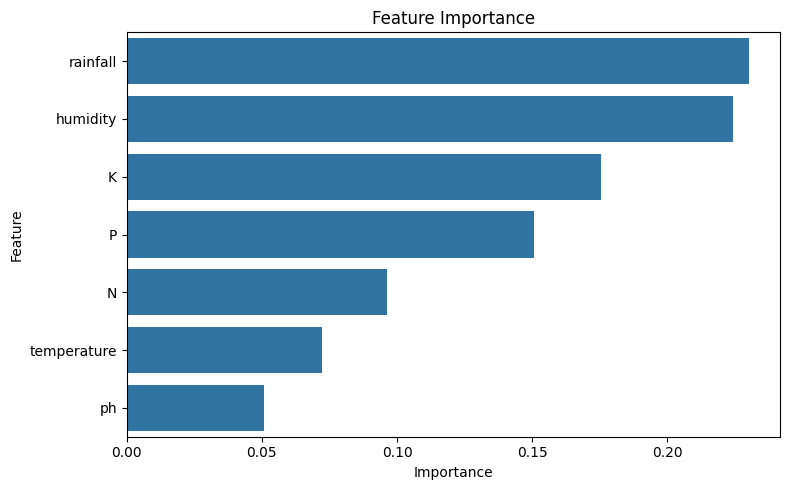

In [91]:
# feature importance graph.

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance')

plt.tight_layout()

plt.savefig(
    '../reports/feature_importance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()